# CS 432 – Databases  
## Assignment 2 – Module A  
### Lightweight DBMS with B+ Tree Index 

---

## Introduction

Efficient data storage and retrieval are fundamental challenges in database systems. As datasets grow larger, performing operations using linear scans becomes inefficient. To address this problem, database systems use indexing structures that enable fast lookup operations.

One of the most widely used indexing structures is the **B+ Tree**. B+ Trees are balanced tree structures that support efficient insertion, deletion, search, and range queries. They are widely used in database management systems and file systems.

In this project, we implement a lightweight database indexing engine using a **B+ Tree** from scratch in Python. The implemented system supports storing records associated with keys and executing efficient database operations. The system is then applied to a ride-sharing dataset.

Additionally, the performance of the B+ Tree is compared with a brute-force database approach to demonstrate the advantages of structured indexing.

## Video Demonstration

https://drive.google.com/file/d/1I9zkvqs1rKnElnve3mL8sAIaEZh10ggV/view?usp=sharing 

## Dataset Description

The dataset for this assignment represents a ride-sharing database.

All tables are stored as CSV files inside the `tables/` directory.

The dataset includes 11 tables such as:

- Members
- ActiveRides
- BookingRequests
- Cancellation
- MemberRatings
- MemberStats
- MessageHistory
- RideFeedback
- RideHistory
- RidePassengerMap
- Vehicles

All CSV files inside the `tables/` directory are automatically detected and loaded.

The database is populated in two stages:
1. The `Vehicles` table is created with an explicit schema and populated record by record — demonstrating the complete manual workflow.
2. The remaining 10 tables are loaded from their CSV files using an explicit primary-key mapping, passing every record through the same `db.insert` pipeline.

This design makes the system scalable to any number of tables.

## System Architecture

The implemented system consists of the following components:

### Database Manager
The DatabaseManager class manages all tables and their corresponding indexes.

### Table Layer
Each table stores records in memory using a dictionary structure.

### B+ Tree Index
The B+ Tree stores keys and references to records. Internal nodes guide the search process, while leaf nodes store the actual key-value pairs.

Leaf nodes are connected using linked pointers, which allows efficient execution of range queries.

In [1]:
import os
import pandas as pd
import random
import time
import matplotlib.pyplot as plt
import tracemalloc
from database import DatabaseManager, BPlusTree, BruteForceDB

## Step 1: Initialize the Database

A `DatabaseManager` instance is created and a named database `rideshare` is registered using `create_database` — exactly as real database systems require a named database before any tables can be created inside it.

In [2]:
db = DatabaseManager()
db.create_database('rideshare')
print("Active databases:", db.list_databases())

Active databases: ['rideshare']


## Step 2: Define Schema and Create a Table — `Vehicles` 

Before any data can be stored, the system must know the **structure** of each table: its column names and expected data types. This schema is passed to `create_table`, which registers the table inside the database and initialises a dedicated B+ Tree index on the primary key.

Below is the **complete step-by-step process** demonstrated for the `Vehicles` table.

In [3]:
# Step 2a: Define schema 
vehicles_schema = {
    'VehicleID':   int,
    'VehicleType': str,
    'MaxCapacity': int,
}

# Step 2b: Create table (registers it + initialises empty B+ Tree) 
db.create_table('Vehicles', 'VehicleID', schema=vehicles_schema, order=5)
print("Tables so far:", db.list_tables())

# Step 2c: Insert each record individually 
vehicles_data = [
    {'VehicleID': 1, 'VehicleType': 'Bike',        'MaxCapacity': 1},
    {'VehicleID': 2, 'VehicleType': 'Auto Rickshaw','MaxCapacity': 3},
    {'VehicleID': 3, 'VehicleType': 'Mini Cab',     'MaxCapacity': 4},
    {'VehicleID': 4, 'VehicleType': 'Sedan Cab',    'MaxCapacity': 4},
    {'VehicleID': 5, 'VehicleType': 'SUV Cab',      'MaxCapacity': 6},
    {'VehicleID': 6, 'VehicleType': 'Premium SUV',  'MaxCapacity': 7},
]
for rec in vehicles_data:
    db.insert('Vehicles', rec)

print(f"Inserted {len(vehicles_data)} vehicle records.")

# Step 2d: Verify via B+ Tree index 
print("\nAll vehicles (sorted by VehicleID via B+ Tree):")
for key, row in db.indexes['Vehicles'].get_all():
    print(f"  VehicleID={key}: {row['VehicleType']}, capacity={row['MaxCapacity']}")

Tables so far: ['Vehicles']
Inserted 6 vehicle records.

All vehicles (sorted by VehicleID via B+ Tree):
  VehicleID=1: Bike, capacity=1
  VehicleID=2: Auto Rickshaw, capacity=3
  VehicleID=3: Mini Cab, capacity=4
  VehicleID=4: Sedan Cab, capacity=4
  VehicleID=5: SUV Cab, capacity=6
  VehicleID=6: Premium SUV, capacity=7


## Step 3: Load Remaining Tables from CSV

The complete walkthrough above — define schema → `create_table` → insert each record individually — is the canonical way to populate any table in this system. For the remaining **10 tables**, the identical process applies.

However, repeating it verbatim for every table would add hundreds of lines of code with no additional instructional value. Instead, the other tables are loaded directly from their CSV files. Every record still passes through `db.insert`, which inserts the key into the B+ Tree index exactly as shown above. The only difference is that `pandas` reads the rows from disk rather than us writing them inline.

In [4]:
TABLES_DIR = 'tables'

pk_columns = {
    'Members':          'MemberID',
    'BookingRequests':  'RequestID',
    'MessageHistory':   'MessageID',
    'MemberStats':      'MemberID',
    'ActiveRides':      'RideID',
    'RideHistory':      'RideID',
    'RideFeedback':     'RideID',
    # These tables have no single unique column — use row index as synthetic PK
    # 'MemberRatings':    None,
    # 'RidePassengerMap': None,
    # 'Cancellation':     None,
}

for table_name, pk_col in pk_columns.items():
    df = pd.read_csv(f"{TABLES_DIR}/{table_name}.csv")
    
    if pk_col is None:
        # No single unique column; use integer row index as synthetic primary key
        pk_col = 'row_id'
        df.insert(0, 'row_id', range(1, len(df) + 1))
    db.create_table(table_name, pk_col, order=5)
    
    for _, row in df.iterrows():
        db.insert(table_name, row.to_dict())
    print(f"  Loaded: {table_name:20s}  ({len(df):3d} rows)  PK = {pk_col}")

print(f"\nTotal tables in database: {len(db.list_tables())}")

  Loaded: Members               ( 30 rows)  PK = MemberID
  Loaded: BookingRequests       ( 20 rows)  PK = RequestID
  Loaded: MessageHistory        ( 20 rows)  PK = MessageID
  Loaded: MemberStats           ( 30 rows)  PK = MemberID
  Loaded: ActiveRides           ( 20 rows)  PK = RideID
  Loaded: RideHistory           ( 40 rows)  PK = RideID
  Loaded: RideFeedback          ( 40 rows)  PK = RideID

Total tables in database: 8


In [5]:
len("119fb431-101b-49d7-be17-92e9caab7c87")

36

## Implementation Details

### B+ Tree Node Structure
The tree uses three classes: a base `Node`, a `LeafNode` (stores key-value pairs, linked prev/next), and an `InternalNode` (stores separator keys and child pointers).

### Insertion
`insert` checks whether the root is full. If so, a new `InternalNode` becomes the root and the old root is split via `_split_child`. Insertion then recurses via `_insert_non_full`. For leaf splits, the middle key is **copied up** to the parent while both halves keep their data. For internal splits, the middle key is **promoted** (removed from the child). Duplicate keys are handled by updating the existing value in place.

### Deletion
`delete` calls the recursive `_delete`. After removing a key from a leaf, the parent checks for underflow (`keys < ⌈order/2⌉ - 1`). Underflow is resolved in order: borrow from left sibling → borrow from right sibling → merge with sibling. After a merge the parent loses a key, which may cascade upward. If the root becomes empty its only child becomes the new root.

### Search
`_find_leaf` traverses internal nodes by comparing against separator keys, then binary search is used within the leaf.

### Range Query
`_find_leaf` locates the start key, then the linked `next` pointers of leaf nodes are followed until the end key is exceeded — no tree traversal needed after the first lookup.

### Update
Finds the correct leaf via `_find_leaf` and overwrites the stored value for the matching key.

## Exact Search — `Members`

Exact search navigates from the B+ Tree root to the correct leaf in **O(log n)** time using separator keys in internal nodes.

We search for **Kiara Singh** (MemberID = `28498441`).

In [6]:
db.search("Members", 28498441)

{'MemberID': 28498441,
 'FullName': 'Kiara Singh',
 'ProfileImageURL': 'https://robohash.org/28498441.png?set=set4',
 'Programme': 'B.Tech.-M.Tech. Dual Degree',
 'Branch': 'Artificial Intelligence',
 'BatchYear': 2028,
 'Email': 'kiara.singh@iitgn.ac.in',
 'ContactNumber': 9146086242,
 'Age': 22,
 'Gender': 'F'}

## Range Query — `MemberStats`

Range queries exploit the **doubly-linked leaf list**: the start key is located in O(log n), then the scan continues forward through leaf pointers collecting every record in range — **O(log n + k)** total, where k is the number of results.

We retrieve ride statistics for members with MemberID between `28498440` and `28498445`.

In [7]:
db.range_query("MemberStats", 28498440, 28498445)

[('28498440.0',
  {'MemberID': 28498440.0,
   'AverageRating': 3.06,
   'TotalRidesTaken': 76.0,
   'TotalRidesHosted': 1.0,
   'NumberOfRatings': 152.0}),
 ('28498441.0',
  {'MemberID': 28498441.0,
   'AverageRating': 3.24,
   'TotalRidesTaken': 100.0,
   'TotalRidesHosted': 99.0,
   'NumberOfRatings': 200.0}),
 ('28498442.0',
  {'MemberID': 28498442.0,
   'AverageRating': 2.0,
   'TotalRidesTaken': 104.0,
   'TotalRidesHosted': 64.0,
   'NumberOfRatings': 208.0}),
 ('28498443.0',
  {'MemberID': 28498443.0,
   'AverageRating': 2.25,
   'TotalRidesTaken': 52.0,
   'TotalRidesHosted': 33.0,
   'NumberOfRatings': 104.0}),
 ('28498444.0',
  {'MemberID': 28498444.0,
   'AverageRating': 3.59,
   'TotalRidesTaken': 103.0,
   'TotalRidesHosted': 49.0,
   'NumberOfRatings': 206.0})]

## Insert Operation — `Vehicles`

A new record is inserted into both the table store and the B+ Tree index simultaneously. When a leaf becomes full it is split and the promoted separator key propagates upward, maintaining balance.

We register a new vehicle type: **Electric Car** (VehicleID = 7).

In [8]:
new_vehicle = {
    'VehicleID':   7,
    'VehicleType': 'Electric Car',
    'MaxCapacity': 5,
}

db.insert('Vehicles', new_vehicle)
print("Inserted. Verify via search:")
db.search('Vehicles', 7)

Inserted. Verify via search:


{'VehicleID': 7, 'VehicleType': 'Electric Car', 'MaxCapacity': 5}

## Update Operation — `Members`

The update operation modifies a record in both the table store and the B+ Tree index.

Member **Navya Shah** (MemberID = `28498458`) has submitted a name correction to **Shah Navya**. All other fields remain unchanged.

In [9]:
print("Before update:", db.search("Members", 28498458))

db.update("Members", 28498458, {'MemberID': 28498458, 'FullName': 'Shah Navya', 'ProfileImageURL': 'https://robohash.org/28498458.png?set=set4', 'Programme': 'M.Tech.', 'Branch': 'Computer Science and Engineering', 'BatchYear': 2031, 'Email': 'navya.shah@iitgn.ac.in', 'ContactNumber': 7405900382, 'Age': 24, 'Gender': 'F'})

print("After update:", db.search("Members", 28498458))

Before update: {'MemberID': 28498458, 'FullName': 'Navya Shah', 'ProfileImageURL': 'https://robohash.org/28498458.png?set=set4', 'Programme': 'M.Tech.', 'Branch': 'Computer Science and Engineering', 'BatchYear': 2031, 'Email': 'navya.shah@iitgn.ac.in', 'ContactNumber': 7405900382, 'Age': 24, 'Gender': 'F'}
After update: {'MemberID': 28498458, 'FullName': 'Shah Navya', 'ProfileImageURL': 'https://robohash.org/28498458.png?set=set4', 'Programme': 'M.Tech.', 'Branch': 'Computer Science and Engineering', 'BatchYear': 2031, 'Email': 'navya.shah@iitgn.ac.in', 'ContactNumber': 7405900382, 'Age': 24, 'Gender': 'F'}


## Delete Operation — `Vehicles`

Deletion removes the record from both the table store and the B+ Tree index. If a leaf node drops below the minimum key count after deletion, the tree rebalances by borrowing from a sibling or merging nodes.

We delete the **Electric Car** (VehicleID = 7) that was inserted above.

In [10]:
print("Before delete:", db.search('Vehicles', 7))

db.delete('Vehicles', 7)

result = db.search('Vehicles', 7)
print("After delete: ", result if result is not None else "Record not found (correctly deleted)")

Before delete: {'VehicleID': 7, 'VehicleType': 'Electric Car', 'MaxCapacity': 5}
After delete:  Record not found (correctly deleted)


## B+ Tree Visualization

The B+ Tree structure is visualized using **Graphviz**, rendered as PNG files saved to `bplustree_images/`.

Each visualization shows:
- **Internal nodes** (blue) — store separator keys that guide traversal
- **Leaf nodes** (green) — store actual key-value pairs
- **Solid arrows** — parent-child edges
- **Dashed grey arrows** — the doubly-linked list connecting leaf nodes

All images are saved to `bplustree_images/` and can be opened at full resolution for detailed inspection. Tables with integer primary keys (e.g. `Vehicles`, `Members`) produce compact trees. Tables with UUID string keys (e.g. `RideHistory`, `ActiveRides`) produce wider trees — this reflects the data, not a limitation of the implementation. The inline previews below are scaled for reference.

## Visualizing Trees for All Tables

All PNG files are written to `bplustree_images/` so they can be opened at full resolution outside the notebook for detailed inspection of each node and its contents.

In [11]:
IMAGE_DIR = "bplustree_images"
os.makedirs(IMAGE_DIR, exist_ok=True)

for table_name in db.indexes:
    filename = os.path.join(IMAGE_DIR, table_name + "_tree")
    db.indexes[table_name].visualize_tree(filename)
    print(f"  Saved: {filename}.png")

print("\nAll tree images saved to bplustree_images/")

  Saved: bplustree_images/Vehicles_tree.png
  Saved: bplustree_images/Members_tree.png
  Saved: bplustree_images/BookingRequests_tree.png
  Saved: bplustree_images/MessageHistory_tree.png
  Saved: bplustree_images/MemberStats_tree.png
  Saved: bplustree_images/ActiveRides_tree.png
  Saved: bplustree_images/RideHistory_tree.png
  Saved: bplustree_images/RideFeedback_tree.png

All tree images saved to bplustree_images/



── Vehicles ──


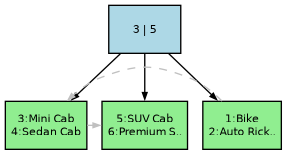


── Members ──


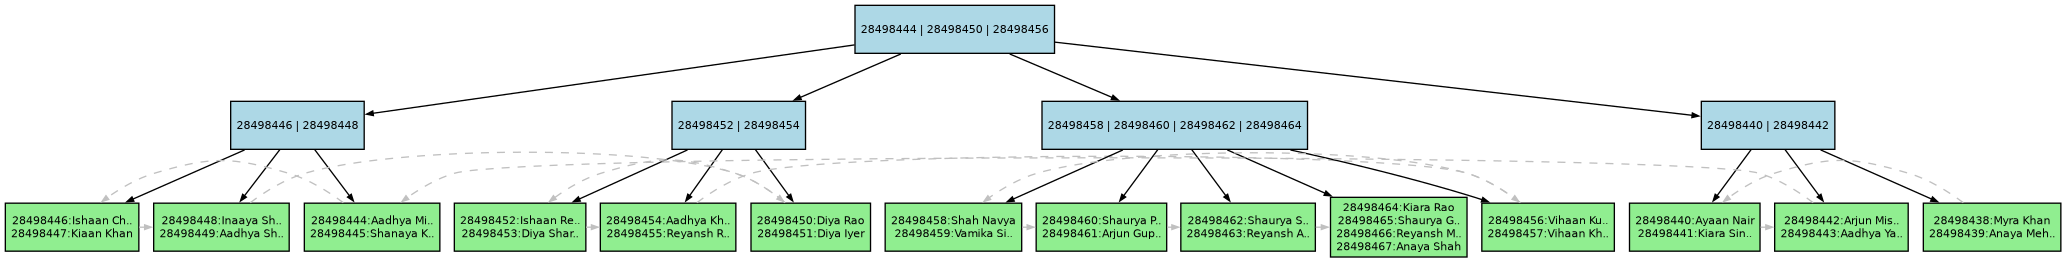


── BookingRequests ──


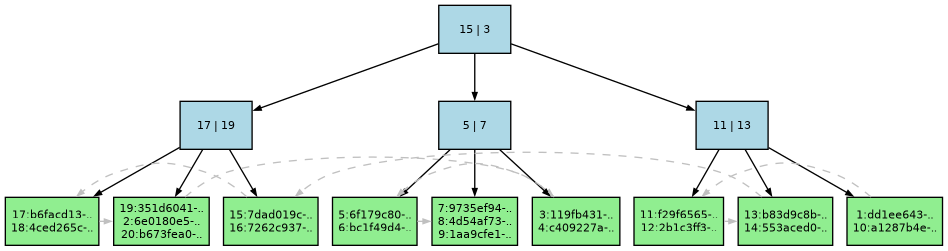


── MessageHistory ──


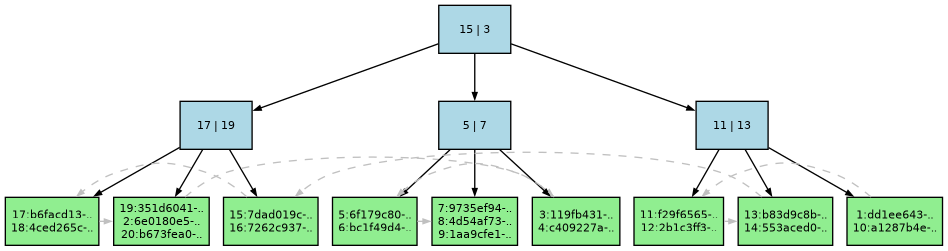


── MemberStats ──


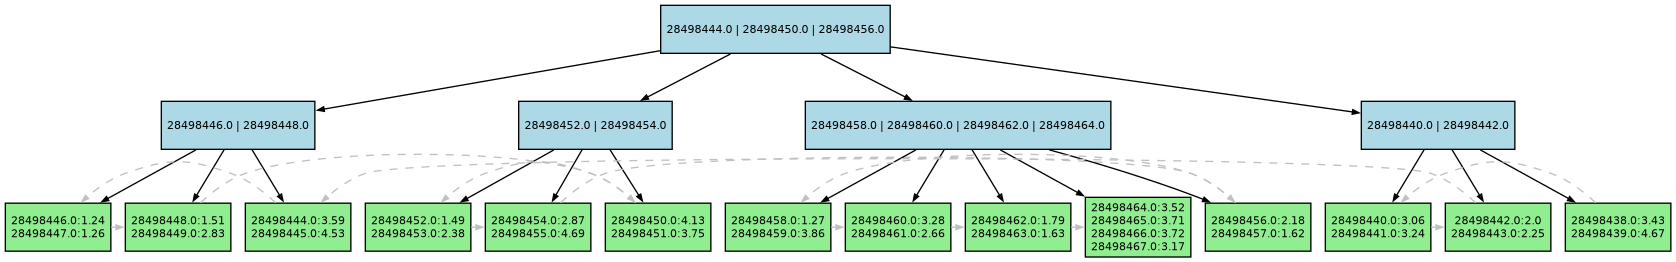


── ActiveRides ──


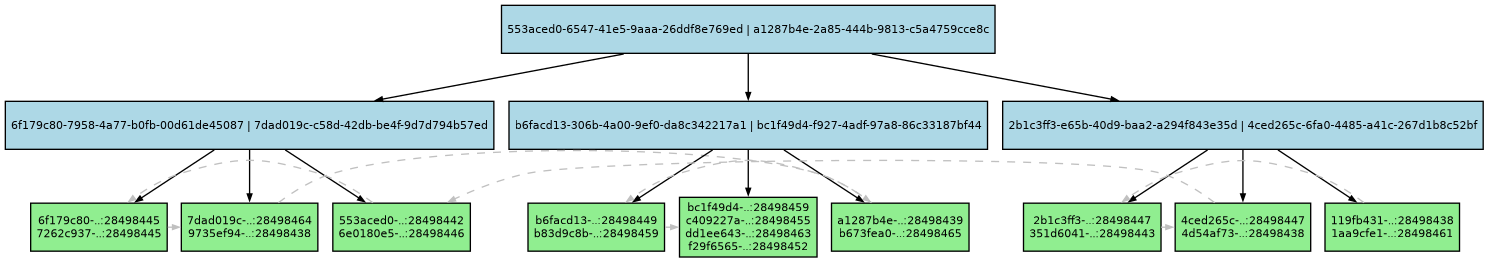


── RideHistory ──


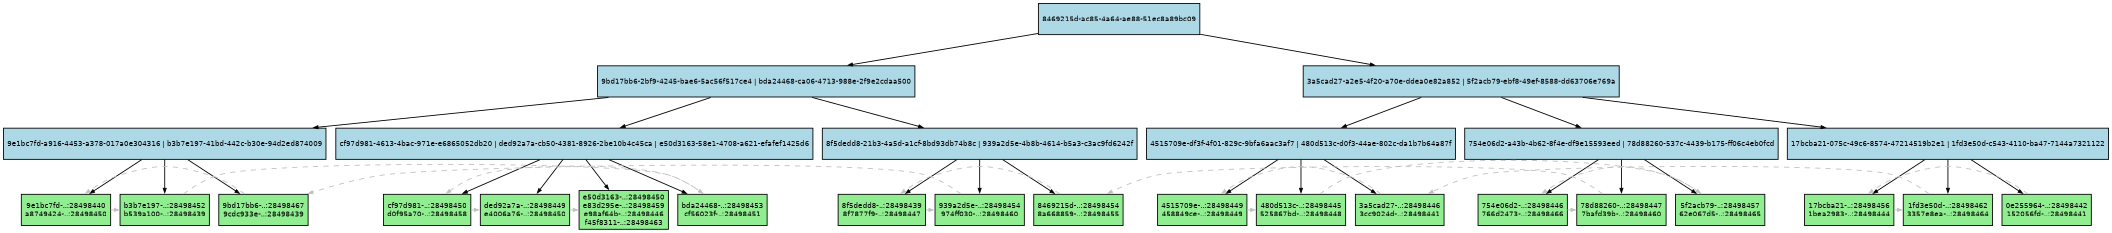


── RideFeedback ──


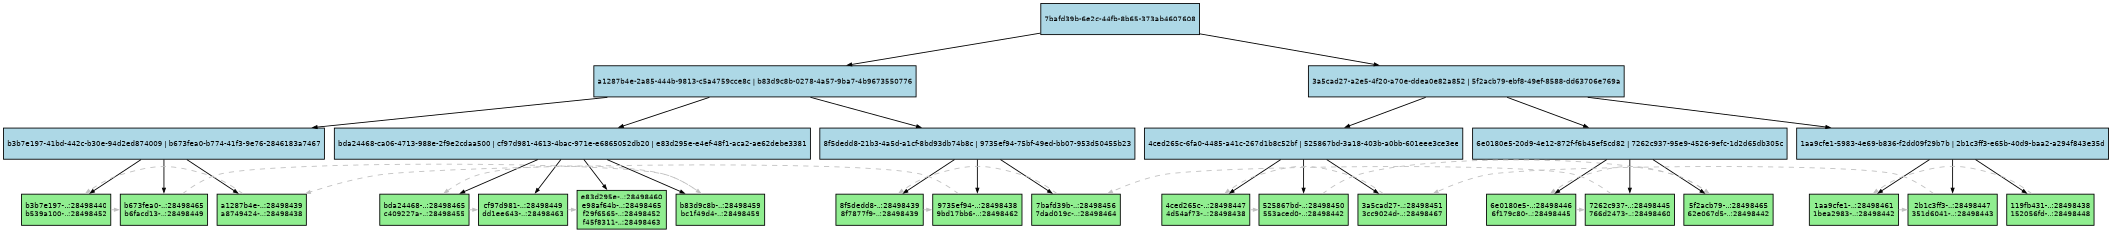

In [12]:
from IPython.display import Image, display

for table_name in db.indexes:
    filename = os.path.join("bplustree_images", table_name + "_tree")
    db.indexes[table_name].visualize_tree(filename)
    print(f"\n── {table_name} ──")
    display(Image(filename + ".png", width=1050))

## Demonstrating Node Split (Insertion)

To illustrate how the B+ Tree structure evolves, we visualize the tree before and after inserting a new key.

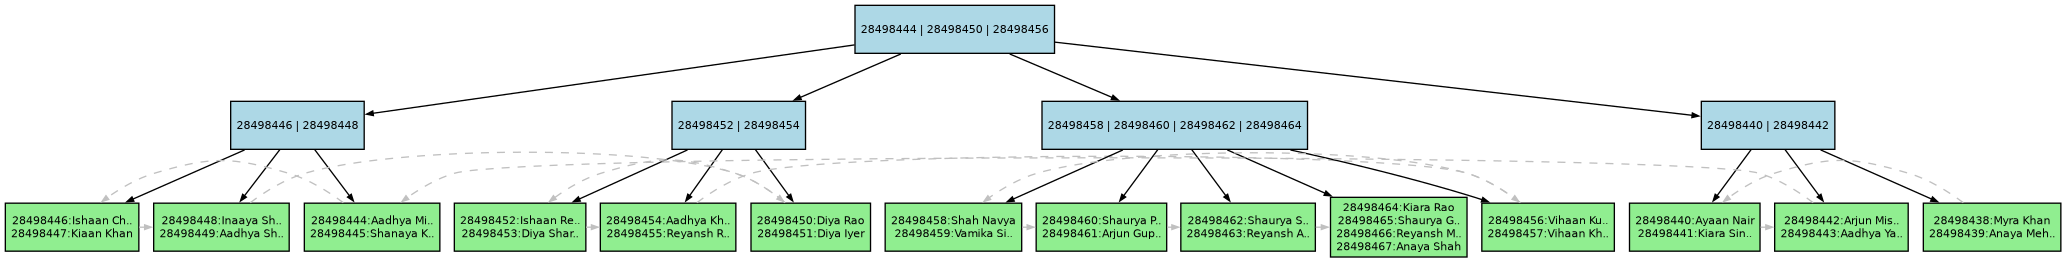

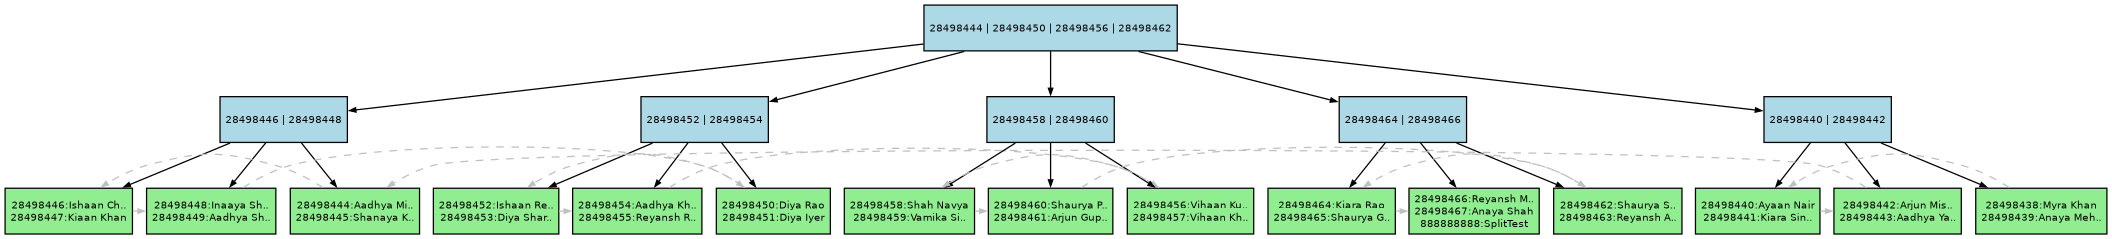

In [13]:
db.indexes["Members"].visualize_tree("bplustree_images/before_insert")
display(Image("bplustree_images/before_insert.png",width=1050))

db.insert("Members",{"MemberID":888888888,"FullName":"SplitTest"})

db.indexes["Members"].visualize_tree("bplustree_images/after_insert")
display(Image("bplustree_images/after_insert.png",width=1050))

## Demonstrating Node Merge (Deletion)

To illustrate how the B+ Tree structure evolves, we visualize the tree before and after deleting a new key.

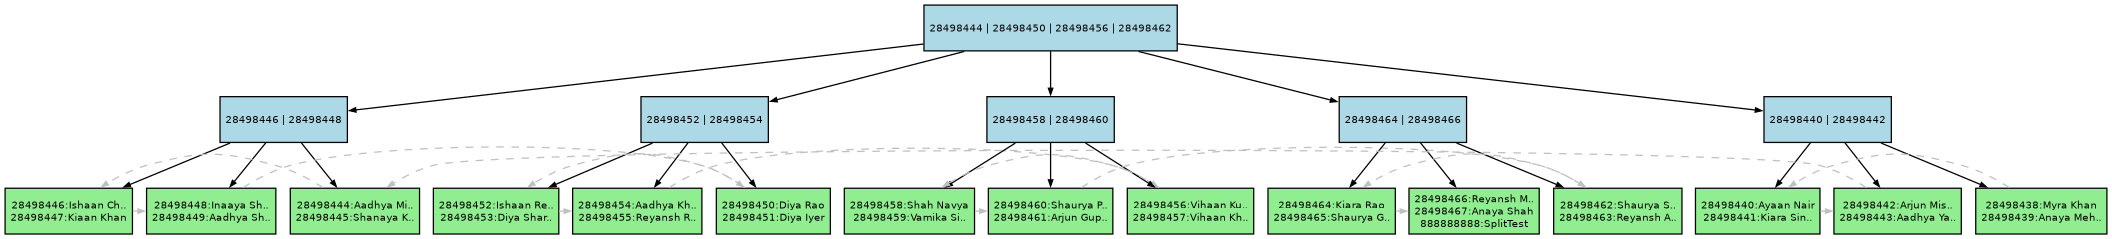

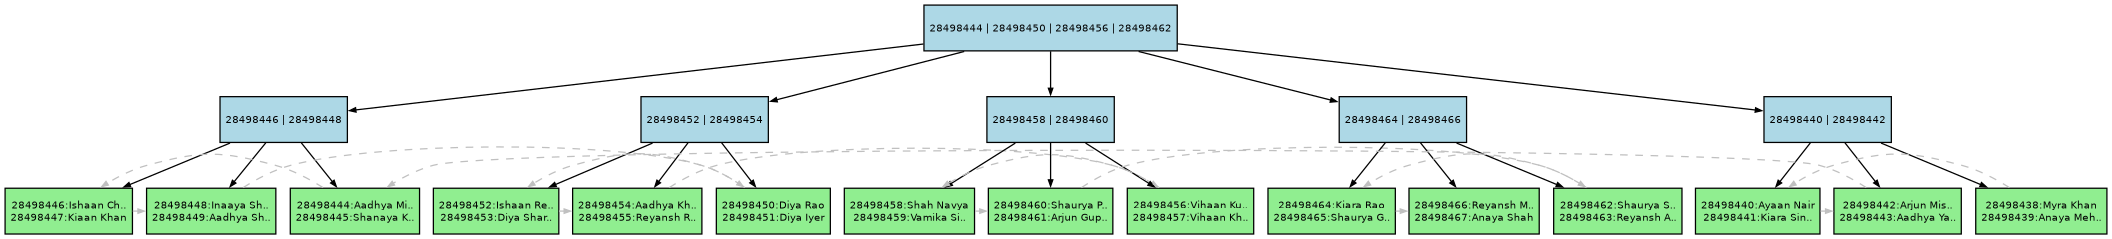

In [14]:
db.indexes["Members"].visualize_tree("bplustree_images/before_delete")
display(Image("bplustree_images/before_delete.png",width=1050))

db.delete("Members",888888888)

db.indexes["Members"].visualize_tree("bplustree_images/after_delete")
display(Image("bplustree_images/after_delete.png",width=1050))

## Performance Analysis

The performance of the B+ Tree is compared with the BruteForceDB implementation.

We measure:

- insertion time
- search time
- deletion time
- range query time
- random workload performance
- memory usage

In [15]:
! rm -rf *.db*

In [16]:
import glob
import os



class PerformanceAnalyzer:
    """
    Measures and compares performance of B+ Tree vs BruteForceDB.
    Tracks: insertion time, search time, deletion time, range query time, memory.
    """

    def __init__(self, sizes=None):
        self.sizes = sizes or list(range(100, 100001, 1000))
        self.results = {
            "sizes": self.sizes,
            "insert_bpt": [], "insert_brute": [],
            "search_bpt": [], "search_brute": [],
            "delete_bpt": [], "delete_brute": [],
            "range_bpt":  [], "range_brute":  [],
        }

    def _measure(self, func, *args):
        start = time.perf_counter()
        func(*args)
        return time.perf_counter() - start

    def run(self):
        for size in self.sizes:
            keys        = random.sample(range(1, size * 10), size)
            search_keys = random.sample(keys, max(1, size // 10))
            delete_keys = random.sample(keys, max(1, size // 10))
            r_start     = random.randint(1, size * 5)
            r_end       = r_start + size // 2

            bpt   = BPlusTree(order=5,filename='./analyzer.db')
            brute = BruteForceDB()

            # Insertion
            self.results["insert_bpt"].append(
                self._measure(lambda: [bpt.insert(k, k) for k in keys]))
            self.results["insert_brute"].append(
                self._measure(lambda: [brute.insert(k) for k in keys]))

            # Search
            self.results["search_bpt"].append(
                self._measure(lambda: [bpt.search(k) for k in search_keys]))
            self.results["search_brute"].append(
                self._measure(lambda: [brute.search(k) for k in search_keys]))

            # Delete
            self.results["delete_bpt"].append(
                self._measure(lambda: [bpt.delete(k) for k in delete_keys]))
            self.results["delete_brute"].append(
                self._measure(lambda: [brute.delete(k) for k in delete_keys]))

            # Range query
            self.results["range_bpt"].append(
                self._measure(bpt.range_query, r_start, r_end))
            self.results["range_brute"].append(
                self._measure(brute.range_query, r_start, r_end))
            
            for f in glob.glob("*.db*"):
                os.remove(f)

        return self.results

    def measure_memory(self, n=5000):
        """
        Compare peak memory usage between BPlusTree and BruteForceDB.
        """
        
        # B+ Tree
        tracemalloc.start()
        t = BPlusTree(order=5)
        for k in range(n): t.insert(k, k)
        _, bpt_peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        # BruteForce
        tracemalloc.start()
        b = BruteForceDB()
        for k in range(n): b.insert(k)
        _, brute_peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        print(f"B+ Tree peak memory   ({n} keys): {bpt_peak/1024:.2f} KB")
        print(f"BruteForce peak memory ({n} keys): {brute_peak/1024:.2f} KB")
        return bpt_peak, brute_peak

In [17]:
analyzer = PerformanceAnalyzer(sizes=list(range(100, 20001, 2000)))
results  = analyzer.run()

sizes       = results["sizes"]
insert_bpt  = results["insert_bpt"];  insert_brute  = results["insert_brute"]
search_bpt  = results["search_bpt"];  search_brute  = results["search_brute"]
delete_bpt  = results["delete_bpt"];  delete_brute  = results["delete_brute"]
range_bpt   = results["range_bpt"];   range_brute   = results["range_brute"]

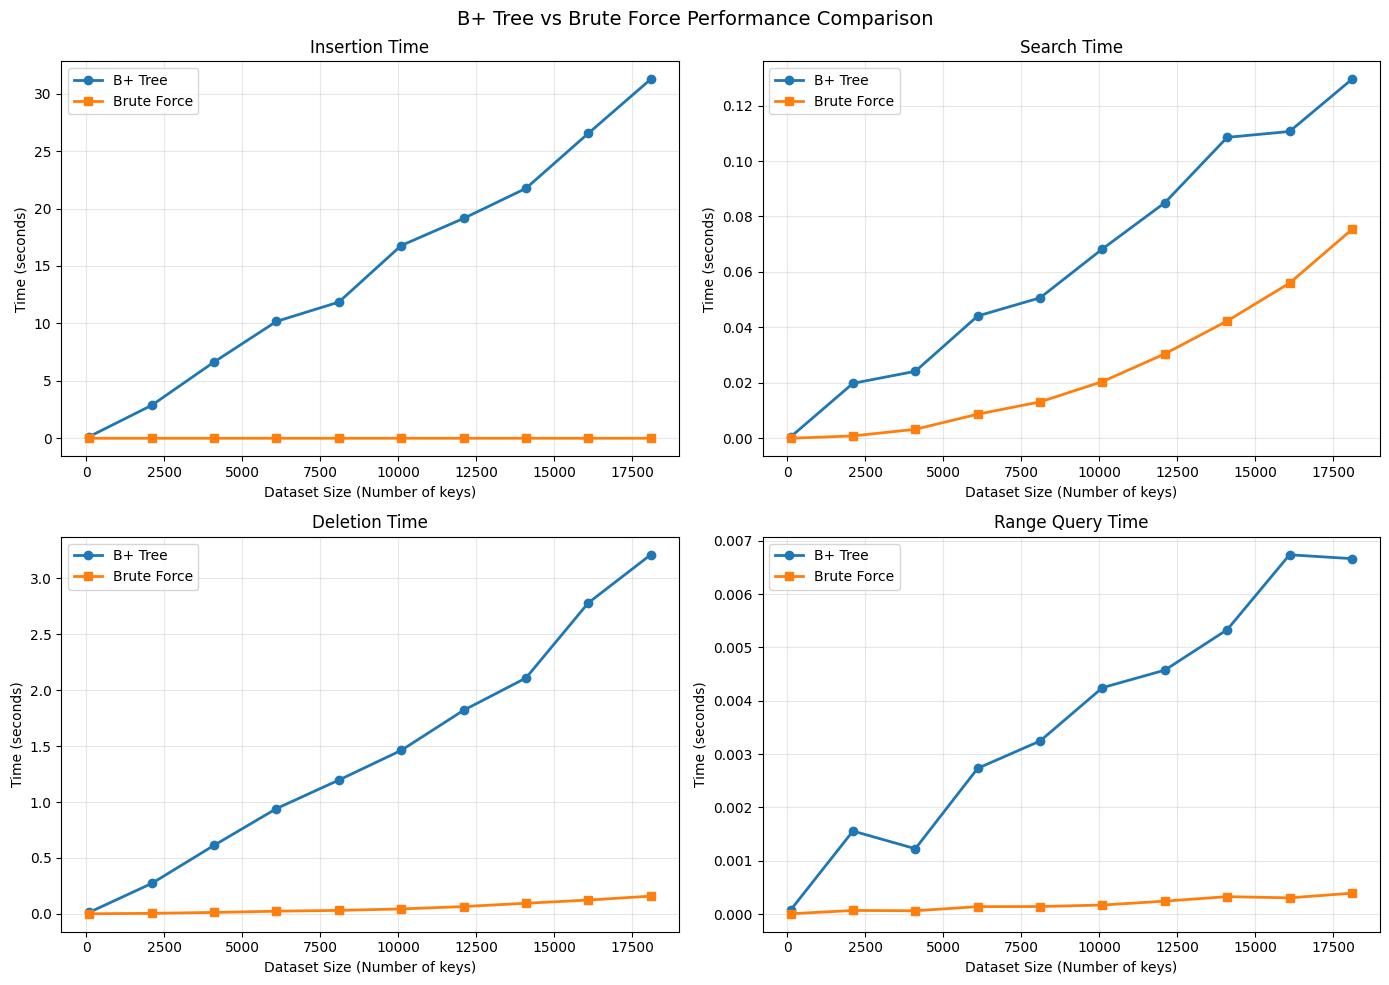

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("B+ Tree vs Brute Force Performance Comparison", fontsize=14)

metrics = [
    ("Insertion Time",    insert_bpt,  insert_brute),
    ("Search Time",       search_bpt,  search_brute),
    ("Deletion Time",     delete_bpt,  delete_brute),
    ("Range Query Time",  range_bpt,   range_brute),
]

for ax, (title, bpt_data, brute_data) in zip(axes.flatten(), metrics):
    ax.plot(sizes, bpt_data,   label="B+ Tree",    marker="o", linewidth=2)
    ax.plot(sizes, brute_data, label="Brute Force", marker="s", linewidth=2)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Dataset Size (Number of keys)", fontsize=10)
    ax.set_ylabel("Time (seconds)", fontsize=10)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("performance_comparison.png", dpi=150)
plt.show()

In [19]:
import pandas as pd

summary = pd.DataFrame({
    "Dataset Size":        sizes,
    "Insert B+Tree (s)":   [round(x, 6) for x in insert_bpt],
    "Insert Brute (s)":    [round(x, 6) for x in insert_brute],
    "Search B+Tree (s)":   [round(x, 6) for x in search_bpt],
    "Search Brute (s)":    [round(x, 6) for x in search_brute],
    "Delete B+Tree (s)":   [round(x, 6) for x in delete_bpt],
    "Delete Brute (s)":    [round(x, 6) for x in delete_brute],
    "Range B+Tree (s)":    [round(x, 6) for x in range_bpt],
    "Range Brute (s)":     [round(x, 6) for x in range_brute],
})
summary

,Dataset Size,Insert B+Tree (s),Insert Brute (s),Search B+Tree (s),Search Brute (s),Delete B+Tree (s),Delete Brute (s),Range B+Tree (s),Range Brute (s)
0,100,0.150453,0.000023,0.000487,0.000009,0.013306,0.000022,0.000074,0.000005
1,2100,2.871264,0.000124,0.019824,0.000860,0.271426,0.003983,0.001557,0.000067
2,4100,6.641285,0.000195,0.024165,0.003244,0.612552,0.012039,0.001225,0.000062
3,6100,10.174127,0.001015,0.044116,0.008695,0.941163,0.023069,0.002733,0.000139
4,8100,11.857802,0.000243,0.050668,0.013134,1.196438,0.030268,0.003245,0.000141
5,10100,16.780343,0.000421,0.068297,0.020447,1.461923,0.043374,0.004245,0.000169
6,12100,19.142234,0.000564,0.084957,0.030454,1.820525,0.064566,0.004574,0.000242
7,14100,21.758460,0.001216,0.108536,0.042315,2.109402,0.094183,0.005332,0.000326
8,16100,26.548510,0.000532,0.110658,0.055980,2.781943,0.122771,0.006737,0.000303
9,18100,31.255714,0.001108,0.129482,0.075323,3.212012,0.157726,0.006665,0.000391


## Random Workload Performance

This test simulates a realistic **mixed-operation stream**: inserts, searches, and deletes are issued in random order against a live B+ Tree. The tree is pre-populated with 5,000 keys so that search and delete operations have valid targets from the start. A further 5,000 random operations are then timed individually.

Results are shown as a per-operation summary table (count + average latency) and a bar chart.

Operation   Count   Total (s)    Avg (µs)
--------------------------------------------
insert       1669    2.529460    1515.554
search       1614    0.290001     179.679
delete       1717    1.364691     794.811
--------------------------------------------
TOTAL        5000    4.184151


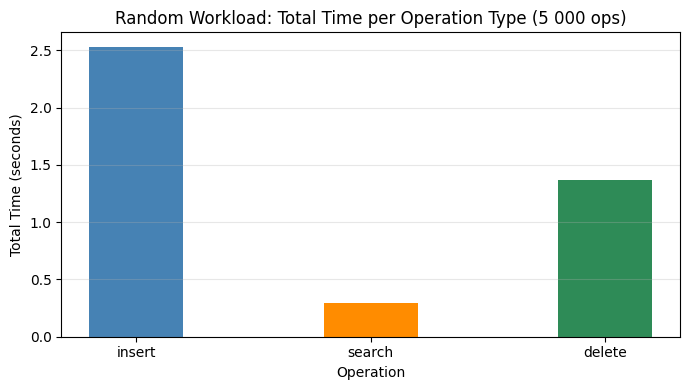

In [20]:
op_list   = ["insert", "search", "delete"]
op_counts = {"insert": 0, "search": 0, "delete": 0}
op_times  = {"insert": 0.0, "search": 0.0, "delete": 0.0}

tree_rw = BPlusTree(order=5,filename='./random.db')
keys_rw = random.sample(range(1, 200_001), 10_000)

# Pre-populate with half the keys so search/delete have valid targets
for k in keys_rw[:5_000]:
    tree_rw.insert(k, k)

# Issue 5 000 random operations and time each individually
for _ in range(5_000):
    op  = random.choice(op_list)
    key = random.choice(keys_rw)
    t0  = time.perf_counter()
    if op == "insert":
        tree_rw.insert(key, key)
    elif op == "search":
        tree_rw.search(key)
    else:
        tree_rw.delete(key)
    op_times[op]  += time.perf_counter() - t0
    op_counts[op] += 1

# Summary table
print(f"{'Operation':<10} {'Count':>6}  {'Total (s)':>10}  {'Avg (µs)':>10}")
print("-" * 44)
total_t = 0.0
for op in op_list:
    cnt = op_counts[op]; tot = op_times[op]
    avg = (tot / cnt * 1e6) if cnt else 0
    total_t += tot
    print(f"{op:<10} {cnt:>6}  {tot:>10.6f}  {avg:>10.3f}")
print("-" * 44)
print(f"{'TOTAL':<10} {sum(op_counts.values()):>6}  {total_t:>10.6f}")

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(op_list, [op_times[o] for o in op_list],
       color=["steelblue", "darkorange", "seagreen"], width=0.4)
ax.set_title("Random Workload: Total Time per Operation Type (5 000 ops)", fontsize=12)
ax.set_xlabel("Operation")
ax.set_ylabel("Total Time (seconds)")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("random_workload.png", dpi=150)
plt.show()

## Memory Usage Analysis

Comparison of peak memory usage between BPlusTree and BruteForceDB is shown.

In [21]:
_ = analyzer.measure_memory(n=5000)

TypeError: BPlusTree.__init__() missing 1 required positional argument: 'filename'

## Results

**Insertion:** B+ Tree insertion is O(log n) — traversal to leaf plus occasional splits. Brute-force append is O(1) but has no indexing benefit for lookups.

**Search:** B+ Tree navigates to the correct leaf in O(log n). Brute-force scans every element — O(n). The gap widens sharply with dataset size.

**Deletion:** B+ Tree locates and removes in O(log n) with possible rebalancing. Brute-force scans to find the key — O(n).

**Range Query:** B+ Tree uses linked leaves: locate start in O(log n), scan forward for k results — O(log n + k). Brute-force inspects every record — O(n).

**Random Workload:** Consistent per-operation latency across all three operation types confirms stable tree performance under mixed realistic access patterns.

**Memory:** The B+ Tree uses more memory than the raw list due to node pointers and structural overhead — the deliberate cost of logarithmic access time.



## Conclusion

A lightweight database indexing engine was implemented using a B+ Tree.

**What was built:**
- A complete B+ Tree with insert, delete, search, range query, and update — with automatic node splitting, merging, and borrowing
- A `Table` abstraction with optional schema validation backed by the B+ Tree
- A `DatabaseManager` with a named-database API: `create_database`, `create_table`, `insert`, `search`, `update`, `delete`, `range_query`, `list_tables`
- A `BruteForceDB` as a performance comparison baseline

**Dataset:** The `Vehicles` table was loaded via explicit record-by-record insertion to demonstrate the full schema-based workflow. The remaining 10 tables were loaded via CSV through the same `db.insert` pipeline.

**Key findings:**
- B+ Tree search and deletion are asymptotically superior to brute force for large datasets
- Range queries benefit most from the linked-leaf structure — O(log n + k) vs O(n)
- The split/merge mechanism keeps the tree balanced at all times